In [ ]:
# 기본
import pandas as pd  # 데이터프레임 처리
import numpy as np  # 수치 계산
import matplotlib.pyplot as plt  # 데이터 시각화
import seaborn as sns  # 고급 시각화

# 경고 뜨지 않게 설정
import warnings  # 경고 무시 설정
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

plt.rcParams['figure.figsize'] = 12, 6  # 그래프 크기 설정
plt.rcParams['font.size'] = 14  # 글자 크기
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder  # 범주형 → 숫자형
from sklearn.preprocessing import StandardScaler  # 데이터 정규화

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split  # 데이터 분할

# 교차 검증
from sklearn.model_selection import cross_val_score  # 교차검증 점수
from sklearn.model_selection import cross_validate  # 교차검증 상세결과
from sklearn.model_selection import KFold  # K겹 검증
from sklearn.model_selection import StratifiedKFold  # 라벨 비율 유지한 K겹

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score  # 정확도
from sklearn.metrics import precision_score  # 정밀도
from sklearn.metrics import recall_score  # 재현율
from sklearn.metrics import f1_score  # F1 점수
from sklearn.metrics import roc_auc_score  # ROC AUC

# 회귀용
from sklearn.metrics import r2_score  # R² 결정계수
from sklearn.metrics import mean_squared_error  # 평균제곱오차

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV  # 그리드서치

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier  # K-최근접 이웃
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀
from sklearn.svm import SVC  # 서포트 벡터 머신
from sklearn.tree import DecisionTreeClassifier  # 결정 트리
from sklearn.ensemble import RandomForestClassifier  # 랜덤 포레스트
from sklearn.ensemble import AdaBoostClassifier  # 아다부스트
from sklearn.ensemble import GradientBoostingClassifier  # 그래디언트 부스팅
from lightgbm import LGBMClassifier  # LightGBM 분류기
from xgboost import XGBClassifier  # XGBoost 분류기
from sklearn.ensemble import VotingClassifier  # 투표 기반 앙상블

# 머신러닝 알고리즘 - 회귀
from sklearn.neighbors import KNeighborsRegressor  # K-최근접 회귀
from sklearn.linear_model import LinearRegression  # 선형 회귀
from sklearn.linear_model import Ridge  # 릿지 회귀
from sklearn.linear_model import Lasso  # 라쏘 회귀
from sklearn.linear_model import ElasticNet  # 엘라스틱넷 회귀
from sklearn.svm import SVR  # 서포트 벡터 회귀
from sklearn.tree import DecisionTreeRegressor  # 결정 트리 회귀
from sklearn.ensemble import RandomForestRegressor  # 랜덤 포레스트 회귀
from sklearn.ensemble import AdaBoostRegressor  # 아다부스트 회귀
from sklearn.ensemble import GradientBoostingRegressor  # 그래디언트 부스팅 회귀
from lightgbm import LGBMRegressor  # LightGBM 회귀
from xgboost import XGBRegressor  # XGBoost 회귀
from sklearn.ensemble import VotingRegressor  # 투표 기반 회귀 앙상블

# 차원 축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 학습 모델 저장을 위한 라이브러리
import pickle



In [ ]:
# 코랩 한국어
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 35 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 3s (4,109 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 126308 files and dire

In [ ]:
plt.rc('font', family='NanumBarunGothic')

 ### 차원의 저주
- 컬럼이 많으면 문제가 발생하는 것을 차원의 저주
- 주어진 입력 데이터의 모든 컬럼들이 서로간에 독립성을 가지고 있고 동시에 결과 데이터와의 종속관계가 매우 크게 되어 있을 확률은 낮다.
- 독립변수끼리의 상관관계는 낮고 독립변수와 종속변수와의 상관관계는 높을 수록 학습에 좋다.
- 따라서 컬럼이 무조건 많다고 좋은 것은 아니다.
- 컬럼이 많으면 데이터를 한번에 시각화 하는 것이 어렵기 때문에 많은 그래프들을 그려봐야 된다.
- 기타 등등....

### 차원 축소
독립변수끼리의 상관관계는 낮고 독립변수와 종속변수와의 상관관계는 높을 수록 학습에 좋다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 차원축소 방식
- PCA : 데이터의 피처들 간의 움직이는 정도인 공분산 행렬을 이용한 차원 축소 방법
- 데이터의 분포 방향을 기준으로 선을 결정한 다음 이 선으로 데이터들을 투영시커 컬럼의 개수를 줄인다.
![](https://velog.velcdn.com/images/chiroya/post/ad40df2d-be5e-4d91-8c46-8c2f858ffcd6/image.png)
- LDA : 주어진 결과데이터를 기반으로 차원을 축소하는 알고리즘
![](https://velog.velcdn.com/images/chiroya/post/98b48658-9b8f-41d9-87eb-0ef33a915084/image.png)

![](https://velog.velcdn.com/images/chiroya/post/a7c15e36-b34d-4ddd-a120-2f99b388e486/image.png)

- PCA 의 사용 목적 : 컬럼의 수를 줄여 데이터 시각화를 용의하게 함에 있다.
- LDA 의 사용 목적 : 결과데이터가 중첩되는 부분을 줄여 좀더 잘 예측수 있게 함에 있다
- PCA로 압축할 경우 상관관계가 높은 입력데이터 X의 컬럼의 수를 줄일 수 있는 부가적인 효과를 얻을 수도 있다.
- 차원 축소를 한다고해서 무조건 학습이 잘 되는 것이 아닌다.
- 너무 적은 수로 축소를 하게되면 오히려 역효과가 발생할 수도 있다.

### PCA

In [ ]:
# 데이터를 읽어온다.
card_df = pd.read_parquet('/content/drive/MyDrive/신용카드데이터.parquet')
test_df = pd.read_parquet('/content/drive/MyDrive/test데이터/신용카드데이터_test.parquet')
target_df = pd.read_csv('/content/drive/MyDrive/Segment.csv')
target_df.head()

,기준년월,ID,Segment
0,201807,TRAIN_000000,D
1,201807,TRAIN_000001,E
2,201807,TRAIN_000002,C
3,201807,TRAIN_000003,D
4,201807,TRAIN_000004,E


In [ ]:
test_df

,기준년월,ID,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,수신거부여부_메일,수신거부여부_DM,이용금액_R3M_신용체크,이용금액_R3M_신용,_1순위카드이용금액,...,청구금액_R3M,청구금액_B0,할인건수_R3M,월중평잔_일시불_B0M,월중평잔_일시불,평잔_일시불_3M,잔액_일시불_B0M,잔액_일시불_B1M,잔액_일시불_B2M,인입횟수_ARS_R6M
0,201807,TEST_00000,1,1,1,1,1,21458,21458,13852,...,11441,4931,1회 이상,6412,5187,3841,4802,2277,0,1회 이상
1,201807,TEST_00001,1,1,0,0,0,18681,10759,11065,...,20522,10152,1회 이상,1010,865,844,1201,1467,544,1회 이상
2,201807,TEST_00002,0,0,0,0,0,40758,40758,27071,...,50508,13223,1회 이상,4407,5591,5606,3046,2496,3096,1회 이상
3,201807,TEST_00003,1,1,0,0,0,5255,5255,4827,...,4604,2112,1회 이상,1107,1545,1510,768,675,1035,1회 이상
4,201807,TEST_00004,1,1,1,1,1,16148,14290,8011,...,6788,4406,1회 이상,1072,1462,1373,637,1395,620,1회 이상
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,201812,TEST_99995,0,0,0,0,0,0,0,0,...,0,0,1회 이상,0,0,0,0,0,0,1회 이상
599996,201812,TEST_99996,0,0,0,0,0,3110,3110,1231,...,1256,359,1회 이상,260,256,237,191,180,238,1회 이상
599997,201812,TEST_99997,0,0,0,0,0,0,0,0,...,0,0,1회 이상,0,0,0,0,0,0,1회 이상
599998,201812,TEST_99998,1,1,1,1,1,173263,113786,63592,...,48141,21273,1회 이상,16911,14005,17039,17916,18779,14586,1회 이상


In [ ]:
설명력기준변수 = ['ID', '기준년월','이용가능여부_해외겸용_본인','보유여부_해외겸용_본인','수신거부여부_TM',
 '수신거부여부_메일','수신거부여부_DM','이용금액_R3M_신용체크','이용금액_R3M_신용',
 '_1순위카드이용금액','이용카드수_신용체크','_2순위카드이용금액','_1순위카드이용건수',
 '_2순위카드이용건수','이용카드수_신용','상향가능한도금액','상향가능CA한도금액','정상청구원금_B5M','정상청구원금_B0M',
 '정상청구원금_B2M','이용금액_일시불_R12M','이용금액_일시불_B0M','이용금액_오프라인_B0M',
 '이용금액_일시불_R6M','이용금액_일시불_R3M','정상입금원금_B5M','정상입금원금_B0M','이용금액_오프라인_R3M',
'이용금액_오프라인_R6M','정상입금원금_B2M','_3순위업종_이용금액','_2순위업종_이용금액','이용건수_신용_R12M',
 '_2순위쇼핑업종_이용금액','최대이용금액_일시불_R12M','이용건수_신판_R12M','이용건수_일시불_R12M',
 '_1순위업종_이용금액','_3순위쇼핑업종_이용금액','이용가맹점수','이용건수_오프라인_B0M',
 '이용건수_오프라인_R6M','이용건수_오프라인_R3M','쇼핑_도소매_이용금액','이용건수_신용_R6M',
 '이용건수_신용_B0M','이용건수_신용_R3M','이용건수_신판_R6M','이용건수_신판_B0M','이용건수_신판_R3M',
 '이용건수_일시불_R6M','이용건수_일시불_B0M','이용건수_일시불_R3M','_1순위교통업종_이용금액','연체입금원금_B0M',
 '쇼핑_마트_이용금액','쇼핑_슈퍼마켓_이용금액','교통_주유이용금액','이용금액_온라인_B0M','연체입금원금_B5M',
 '연체입금원금_B2M','이용금액_페이_온라인_B0M','_1순위쇼핑업종_이용금액','연속유실적개월수_기본_24M_카드',
 '이용금액대','청구금액_R6M','청구금액_R3M','청구금액_B0','할인건수_R3M','월중평잔_일시불_B0M',
 '월중평잔_일시불','평잔_일시불_3M','잔액_일시불_B0M','잔액_일시불_B1M','잔액_일시불_B2M','인입횟수_ARS_R6M']

In [ ]:
train_df = card_df[설명력기준변수]
test_df = test_df[설명력기준변수]

In [ ]:
# 병합
train_df = pd.merge(train_df, target_df, on=['ID', '기준년월'], how='inner')
# train_df

In [ ]:
### 인코딩한다
train_df['이용금액대'] = train_df['이용금액대'].factorize()[0]
train_df['상향가능한도금액'] = train_df['상향가능한도금액'].factorize()[0]
train_df['상향가능CA한도금액'] = train_df['상향가능CA한도금액'].factorize()[0]
train_df['보유여부_해외겸용_본인'] = train_df['보유여부_해외겸용_본인'].factorize()[0]
train_df['이용가능여부_해외겸용_본인'] = train_df['이용가능여부_해외겸용_본인'].factorize()[0]
train_df['할인건수_R3M'] = train_df['할인건수_R3M'].factorize()[0]
train_df['인입횟수_ARS_R6M'] = train_df['인입횟수_ARS_R6M'].factorize()[0]
train_df['수신거부여부_TM'] = train_df['수신거부여부_TM'].factorize()[0]
train_df['수신거부여부_메일'] = train_df['수신거부여부_메일'].factorize()[0]
train_df['수신거부여부_DM'] = train_df['수신거부여부_DM'].factorize()[0]

In [ ]:
### 인코딩한다
test_df['이용금액대'] = test_df['이용금액대'].factorize()[0]
test_df['상향가능한도금액'] = test_df['상향가능한도금액'].factorize()[0]
test_df['상향가능CA한도금액'] = test_df['상향가능CA한도금액'].factorize()[0]
test_df['보유여부_해외겸용_본인'] = test_df['보유여부_해외겸용_본인'].factorize()[0]
test_df['이용가능여부_해외겸용_본인'] = test_df['이용가능여부_해외겸용_본인'].factorize()[0]
test_df['할인건수_R3M'] = test_df['할인건수_R3M'].factorize()[0]
test_df['인입횟수_ARS_R6M'] = test_df['인입횟수_ARS_R6M'].factorize()[0]
test_df['수신거부여부_TM'] = test_df['수신거부여부_TM'].factorize()[0]
test_df['수신거부여부_메일'] = test_df['수신거부여부_메일'].factorize()[0]
test_df['수신거부여부_DM'] = test_df['수신거부여부_DM'].factorize()[0]

In [ ]:
test_df.to_parquet('encoded_test_df.parquet', index=False)
train_df.to_parquet('encoded_train_df.parquet', index=False)

In [ ]:
test_df.drop(['ID','기준년월'], axis=1, inplace=True)
train_df.drop(['ID','기준년월'], axis=1, inplace=True)

In [ ]:
# pca 사용
# n_components : 축소될 결과의 컬럼 개수
pca = PCA(n_components=20)
# 결과 데이터를 제거한다.
X = train_df.drop('Segment', axis=1)
# 학습한다.
pca.fit(X)
# 데이터를 변환한다.
r1 = pca.transform(X)
r1

array([[-2.24355293e+03,  7.31778228e+04, -2.33070671e+04, ...,
         7.04145537e+03, -6.70054710e+02,  1.07835541e+03],
       [-4.12359358e+03, -1.85967998e+04, -5.28155393e+03, ...,
         6.73134529e+02,  6.57221494e+02,  1.47514117e+03],
       [ 9.38444950e+04,  1.23215256e+05, -2.11108391e+04, ...,
        -7.47349425e+02, -2.80012061e+03,  1.23051842e+03],
       ...,
       [ 1.75905958e+04,  3.33447438e+03,  5.99649294e+03, ...,
         1.68224855e+03, -4.05046697e+02,  3.02598915e+02],
       [-7.50896539e+04, -3.66573195e+03, -3.62002012e+03, ...,
        -2.50279003e+02,  3.77937102e+00, -2.34113636e+02],
       [-3.57877045e+04,  4.33569086e+03,  7.98641356e+03, ...,
         2.21961165e+02, -6.57876420e+02,  4.50114419e+01]])

In [ ]:
test_pca = pca.transform(test_df)

In [ ]:
# transform된 test_pca를 parquet파일로 내보낸다.
test_pca_df = pd.DataFrame(test_pca, columns=[f'p{i+1}' for i in range(test_pca.shape[1])])
test_pca_df.to_parquet('test_pca.parquet', index=False)

In [ ]:
test_pca_df

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14,p15,p16,p17,p18,p19,p20
0,5449.770399,-15457.518923,7975.048624,-2971.418082,-1137.004720,4011.962214,11551.144045,3357.707219,-2924.619961,-1328.630829,6456.306948,5052.190399,-1758.037008,757.974686,-3801.911975,-3675.470214,89.699894,192.708209,-2603.045347,6486.179120
1,-39956.605716,26232.031295,1163.543135,-8719.802068,-6359.839526,-9991.101935,-4302.131549,15137.268688,10291.412329,815.171496,1105.501987,2826.930744,4697.819084,3187.565765,-1314.235267,-2610.468020,1837.496242,2076.203385,2799.656647,-765.383592
2,91343.368168,20400.129647,49117.164561,18297.225673,-3701.289750,445.182607,-8089.748593,9430.604063,-8090.458211,-63.631244,-2532.892084,6031.427744,-2219.302720,-1307.780108,35.376295,1316.920654,569.088409,-2300.245020,-2180.985726,1976.296339
3,-60622.721453,-2779.211142,172.147101,-1520.579240,494.335640,-2245.292728,-2498.491927,4213.196652,2446.223055,-925.403803,2079.755754,2406.735903,-1541.601982,2355.289054,-669.735345,253.566145,-410.776255,611.909119,677.146892,1175.953003
4,-48203.789469,188.499891,8676.875441,-8345.019485,-4152.234122,-8421.964890,-2943.931765,4537.336623,1748.248608,-1903.155119,2405.428335,4011.805170,436.572392,3449.701387,-1297.313124,-1117.081428,114.225211,538.235245,1567.426358,490.377240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
599995,-75126.065178,-3705.200669,-3607.179085,706.459161,88.174555,-1576.755865,-1673.193124,66.734119,-311.373335,-693.622302,-303.601312,134.738903,-1061.311309,712.393919,-111.395017,115.492271,108.838629,-99.179137,52.185986,25.174936
599996,-69393.140779,-2960.239513,-1778.824780,-236.728841,-975.862257,-3279.293100,-1335.075257,1572.949223,733.136011,-850.853958,442.423456,-101.670020,725.816597,760.382533,582.392682,871.562343,-175.810487,1104.853566,-301.709955,-972.853643
599997,-75112.821137,-3689.619019,-3601.622699,707.283479,73.604402,-1557.581432,-1663.292202,80.980237,-310.201036,-691.082195,-243.946034,55.711326,-967.948405,675.508403,-100.595249,138.351910,107.394475,-24.579676,64.067690,53.626987
599998,429765.434664,-147776.679157,-45333.927657,-79709.429111,-51300.598712,-19337.740260,4039.117738,2184.738332,42456.455292,14162.848902,9130.737374,-30639.249248,-12570.518026,-12338.005664,52.894266,-1217.003939,16497.104539,-3638.910629,1245.666856,1028.243296


In [ ]:
# 각 주성분이 설명하는 분산 비율
explained_var_ratio = pca.explained_variance_ratio_

# 누적 분산합 계산
cumulative_var_ratio = explained_var_ratio.cumsum()

# 보기 좋게 출력 (DataFrame)
result_df = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained_var_ratio))],
    'Explained Variance Ratio': explained_var_ratio,
    'Cumulative Explained Variance': cumulative_var_ratio
})

print(result_df)

      PC  Explained Variance Ratio  Cumulative Explained Variance
0    PC1                  0.823920                       0.823920
1    PC2                  0.089306                       0.913226
2    PC3                  0.026687                       0.939914
3    PC4                  0.016676                       0.956589
4    PC5                  0.011353                       0.967943
5    PC6                  0.006302                       0.974244
6    PC7                  0.005089                       0.979334
7    PC8                  0.004369                       0.983702
8    PC9                  0.002801                       0.986504
9   PC10                  0.002446                       0.988950
10  PC11                  0.002169                       0.991119
11  PC12                  0.001843                       0.992962
12  PC13                  0.001334                       0.994296
13  PC14                  0.001076                       0.995372
14  PC15  

In [ ]:
10/0

In [ ]:
pca_components = pd.DataFrame(pca.components_,
                               columns=train_df.drop('Segment', axis=1).columns,
                               index=[f'p{i+1}' for i in range(pca.n_components_)])
pca_components

,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,수신거부여부_메일,수신거부여부_DM,이용금액_R3M_신용체크,이용금액_R3M_신용,_1순위카드이용금액,이용카드수_신용체크,_2순위카드이용금액,...,청구금액_R3M,청구금액_B0,할인건수_R3M,월중평잔_일시불_B0M,월중평잔_일시불,평잔_일시불_3M,잔액_일시불_B0M,잔액_일시불_B1M,잔액_일시불_B2M,인입횟수_ARS_R6M
p1,7.881979e-07,5.929148e-07,4.725392e-07,4.379121e-07,4.367648e-07,0.204094,0.202691,0.132730,5.064627e-06,0.044561,...,0.196747,0.063447,1.638855e-06,0.052332,0.051242,0.054778,0.044341,0.046641,0.046802,-1.585139e-07
p2,3.422140e-07,2.956462e-07,-8.207606e-07,-7.831961e-07,-8.078633e-07,-0.047295,-0.041628,-0.016251,-1.081534e-06,-0.017671,...,0.340864,0.104889,-7.875029e-07,-0.011179,-0.010103,-0.009970,-0.003473,0.000258,0.001241,-1.131097e-06
p3,1.181738e-06,7.289834e-07,-2.814743e-07,-3.044689e-07,-2.561162e-07,0.341948,0.269260,0.137947,1.290101e-05,0.101481,...,0.011171,0.011974,3.855585e-06,-0.011238,-0.001476,0.001465,-0.007763,-0.006238,-0.003067,-3.060030e-07
p4,-1.581417e-06,-1.437586e-06,-1.381237e-06,-1.107458e-06,-1.232100e-06,-0.484040,-0.348635,-0.049405,-2.148198e-05,-0.250438,...,-0.106655,-0.061563,-7.037193e-06,-0.095266,-0.095766,-0.086591,-0.092661,-0.114946,-0.110481,-2.226404e-07
p5,-2.649350e-07,-2.858530e-07,-8.488361e-07,-7.600943e-07,-7.916612e-07,-0.242299,-0.137369,-0.001689,-9.641927e-06,-0.111564,...,0.052040,0.030358,-2.392066e-06,0.360463,0.350086,0.353694,0.346034,0.434325,0.421026,-3.053537e-07
p6,4.739780e-07,-2.383977e-07,-4.338794e-07,-2.813960e-07,-3.492388e-07,-0.357718,-0.103401,0.214098,-2.149801e-05,-0.292886,...,0.172325,0.059362,-2.725441e-06,-0.090350,-0.062907,-0.049119,-0.093667,-0.105685,-0.084230,5.593357e-07
p7,2.865326e-06,2.376606e-06,6.145404e-07,7.983708e-07,6.945812e-07,0.172475,-0.008809,0.018043,6.912092e-06,-0.029613,...,-0.243497,-0.073507,-1.573628e-06,-0.005928,0.042070,0.112459,-0.011894,0.004731,0.029857,-7.100258e-07
p8,-1.128177e-07,-1.246667e-07,-1.807161e-06,-1.637106e-06,-1.727300e-06,0.027198,-0.003814,0.128360,-1.182782e-05,-0.125521,...,0.654416,0.240860,-7.135360e-06,-0.020233,0.017153,0.026956,-0.036861,-0.011498,-0.006545,-2.869652e-07
p9,2.027437e-06,1.879578e-06,-1.517907e-06,-9.984484e-07,-1.147316e-06,0.204356,-0.156228,0.285301,-2.105582e-05,-0.402607,...,-0.299092,-0.074722,-9.419840e-06,0.033289,0.014445,0.006915,0.031771,0.028718,0.015697,-1.293309e-06
p10,6.138943e-06,5.526612e-06,1.063807e-06,1.992524e-06,1.885218e-06,0.555430,-0.458517,-0.002437,5.132976e-07,-0.447764,...,0.086139,-0.000924,-1.061741e-05,-0.002963,-0.023608,-0.032888,0.002106,0.009628,0.015938,2.439904e-07


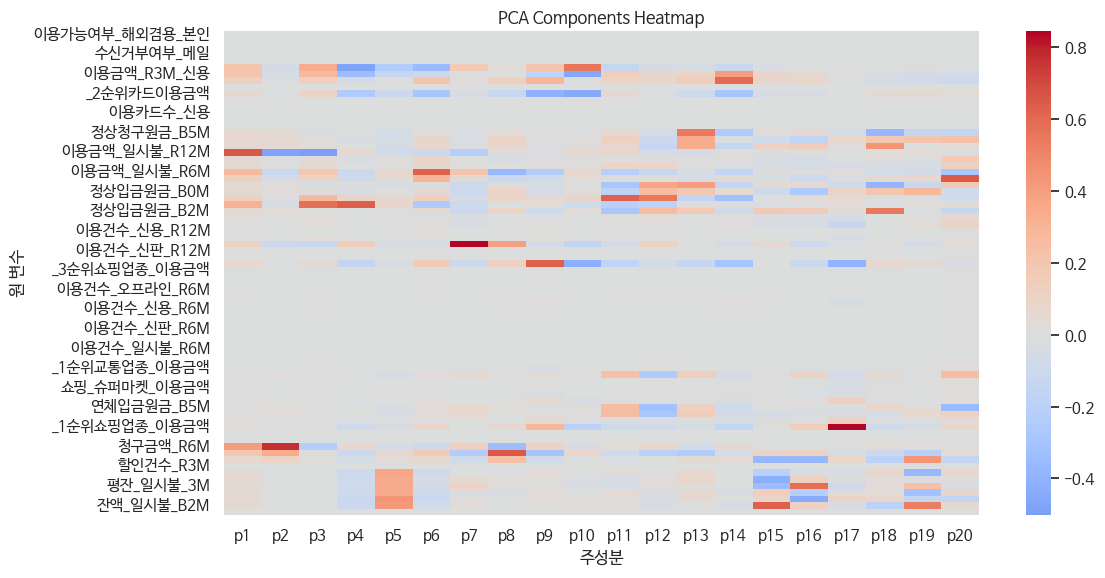

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(pca_components.T, cmap='coolwarm', center=0)
plt.title('PCA Components Heatmap')
plt.xlabel('주성분')
plt.ylabel('원 변수')
plt.tight_layout()
plt.show()

### LDA

In [ ]:
encoder = LabelEncoder()
train_df['Segment'] = encoder.fit_transform(train_df['Segment'])
train_df

,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,수신거부여부_메일,수신거부여부_DM,이용금액_R3M_신용체크,이용금액_R3M_신용,_1순위카드이용금액,이용카드수_신용체크,_2순위카드이용금액,...,청구금액_B0,할인건수_R3M,월중평잔_일시불_B0M,월중평잔_일시불,평잔_일시불_3M,잔액_일시불_B0M,잔액_일시불_B1M,잔액_일시불_B2M,인입횟수_ARS_R6M,Segment
0,0,0,0,0,0,196,196,3681,1,0,...,12226,0,1084,1503,1791,998,736,1083,0,3
1,0,0,0,0,0,13475,13475,13323,1,0,...,5834,0,4090,4447,3761,2565,6795,1424,1,4
2,1,1,0,0,0,23988,23988,24493,1,0,...,21866,0,5006,5540,6796,5312,5150,6143,1,2
3,1,1,0,0,0,3904,3904,5933,1,0,...,16356,0,487,606,772,730,462,708,0,3
4,1,1,0,0,0,1190,0,0,1,0,...,0,0,0,0,0,0,0,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,1,1,0,0,0,10755,7267,5640,1,0,...,0,0,0,0,0,0,0,0,1,4
2399996,1,1,0,0,0,27636,27636,26357,1,0,...,14402,0,4412,5515,9424,3351,4142,4362,1,3
2399997,1,1,1,1,1,23187,23187,17171,1,0,...,5731,0,2694,3046,2998,2524,1523,2898,1,2
2399998,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,4


In [ ]:
# 입력과 결과로 나눈다.
X = train_df.drop('Segment', axis=1)
y = train_df['Segment']
X_LDAtest = test_df.copy()
display(X)
display(y)

,이용가능여부_해외겸용_본인,보유여부_해외겸용_본인,수신거부여부_TM,수신거부여부_메일,수신거부여부_DM,이용금액_R3M_신용체크,이용금액_R3M_신용,_1순위카드이용금액,이용카드수_신용체크,_2순위카드이용금액,...,청구금액_R3M,청구금액_B0,할인건수_R3M,월중평잔_일시불_B0M,월중평잔_일시불,평잔_일시불_3M,잔액_일시불_B0M,잔액_일시불_B1M,잔액_일시불_B2M,인입횟수_ARS_R6M
0,0,0,0,0,0,196,196,3681,1,0,...,46588,12226,0,1084,1503,1791,998,736,1083,0
1,0,0,0,0,0,13475,13475,13323,1,0,...,10530,5834,0,4090,4447,3761,2565,6795,1424,1
2,1,1,0,0,0,23988,23988,24493,1,0,...,85931,21866,0,5006,5540,6796,5312,5150,6143,1
3,1,1,0,0,0,3904,3904,5933,1,0,...,61518,16356,0,487,606,772,730,462,708,0
4,1,1,0,0,0,1190,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,1,1,0,0,0,10755,7267,5640,1,0,...,0,0,0,0,0,0,0,0,0,1
2399996,1,1,0,0,0,27636,27636,26357,1,0,...,37515,14402,0,4412,5515,9424,3351,4142,4362,1
2399997,1,1,1,1,1,23187,23187,17171,1,0,...,22274,5731,0,2694,3046,2998,2524,1523,2898,1
2399998,0,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


,Segment
0,3
1,4
2,2
3,3
4,4
...,...
2399995,4
2399996,3
2399997,2
2399998,4


In [ ]:
# 차원축소
# PCA
pca = PCA(n_components=20)
pca_X = pca.fit_transform(X)

# LDA
lda = LinearDiscriminantAnalysis(n_components=4)
lda_X = lda.fit_transform(X, y)

X_test_lda = lda.transform(X_LDAtest)  # transform만

In [ ]:
# X_test_lda 데이터프레임을 parquet으로 저장한다.
X_test_lda_df = pd.DataFrame(X_test_lda, columns=[f'LD{i+1}' for i in range(X_test_lda.shape[1])])
X_test_lda_df
# 데이터프레임을 parquet으로 내보낸다.
X_test_lda_df.to_parquet('/content/drive/MyDrive/test데이터/X_test_lda.parquet', index=False)

In [ ]:
# GPU 사용 모델로 수정
model1 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)
model2 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)
model3 = XGBClassifier(tree_method='gpu_hist', predictor='gpu_predictor',
                       n_jobs=-1, verbosity=0, use_label_encoder=False)

# 교차 검증 설정
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# 교차 검증 수행 (원본, PCA, LDA)
r1 = cross_val_score(model1, X, y, scoring='accuracy', cv=kfold)
r2 = cross_val_score(model2, pca_X, y, scoring='accuracy', cv=kfold)
r3 = cross_val_score(model3, lda_X, y, scoring='accuracy', cv=kfold)

# 평균 정확도 출력
print("원본 데이터 평균 정확도:", r1.mean())
print("PCA 적용 평균 정확도:", r2.mean())
print("LDA 적용 평균 정확도:", r3.mean())

원본 데이터 평균 정확도: 0.8969000000000001
PCA 적용 평균 정확도: 0.8735220833333333
LDA 적용 평균 정확도: 0.87495625


In [ ]:
# DataFrame으로 저장
pca_df = pd.DataFrame(pca_X, columns=[f'PC{i+1}' for i in range(pca_X.shape[1])])
lda_df = pd.DataFrame(lda_X, columns=[f'LD{i+1}' for i in range(lda_X.shape[1])])
lda_df['Segment'] = y.values  # y가 Series일 경우

# CSV로 저장
pca_df.to_parquet('pca_result20.parquet', index=False)
# CSV 저장
lda_df.to_parquet('lda_result4.csv', index=False)

In [ ]:
num_components = pca_X.shape[1]  # 20
pca_df = pd.DataFrame(pca_X, columns=[f'p{i+1}' for i in range(num_components)])
pca_df['Segment'] = train_df['Segment']  # 타깃 붙이기

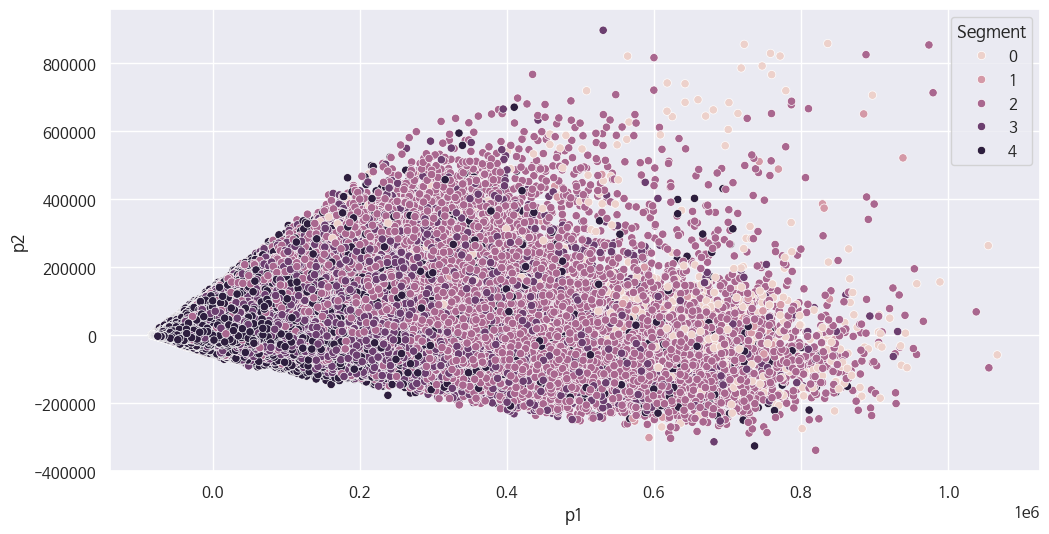

In [ ]:
sns.scatterplot(data=pca_df, x='p1', y='p2',hue='Segment')
plt.show()

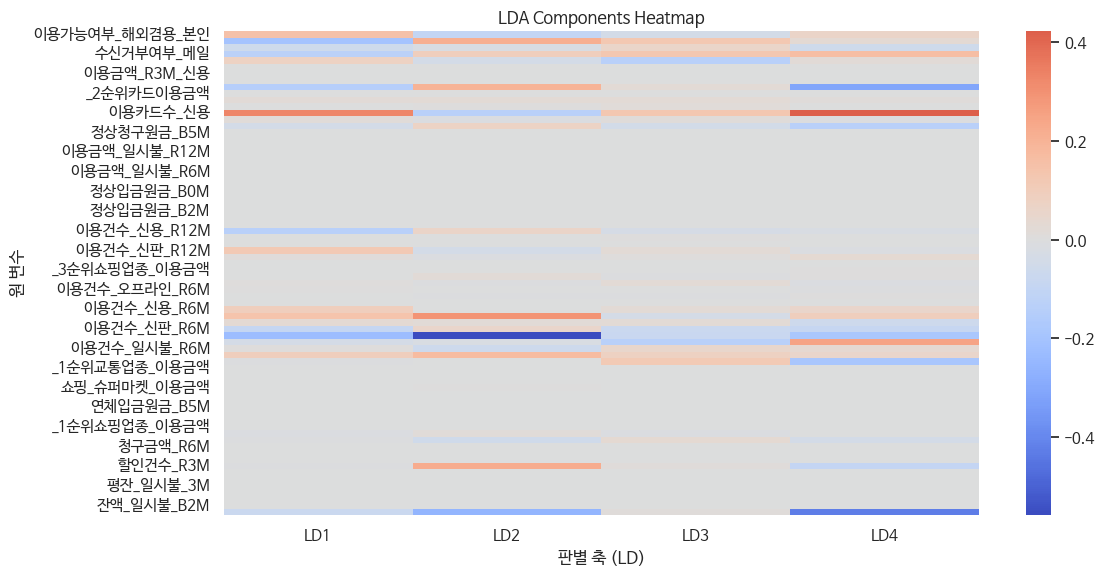

In [ ]:
# 변수명 가져오기
features = train_df.drop('Segment', axis=1).columns

# LDA 판별 축 벡터 (scalings_)를 DataFrame으로 변환
lda_components = pd.DataFrame(lda.scalings_,
                              index=features,
                              columns=[f'LD{i+1}' for i in range(lda.scalings_.shape[1])])

# 시각화
plt.figure(figsize=(12, 6))
sns.heatmap(lda_components, cmap='coolwarm', center=0)
plt.title('LDA Components Heatmap')
plt.xlabel('판별 축 (LD)')
plt.ylabel('원 변수')
plt.tight_layout()
plt.show()

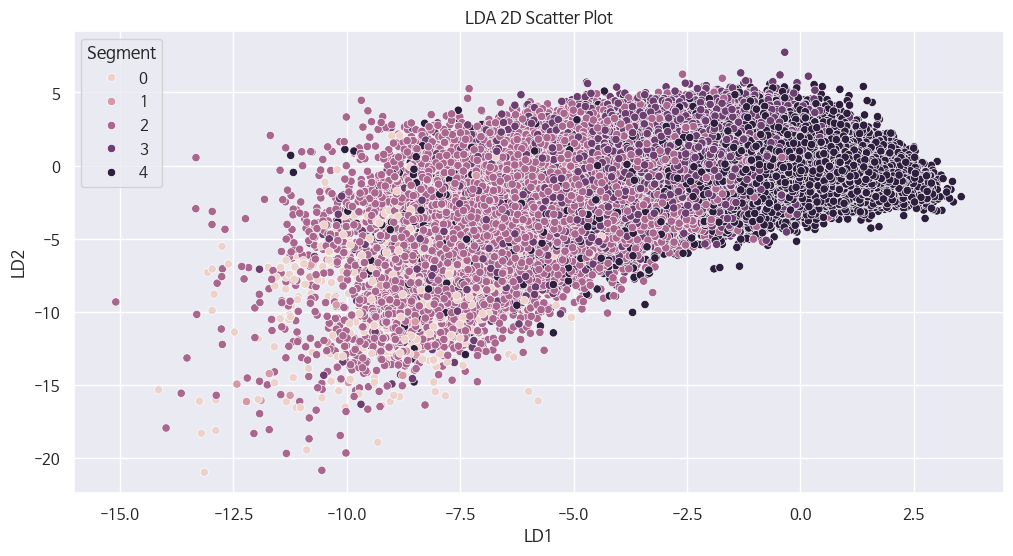

In [ ]:
# 데이터프레임 만들기 (판별 축 1, 2 컬럼)
lda_df = pd.DataFrame(lda_X, columns=[f'LD{i+1}' for i in range(lda_X.shape[1])])

# 원본 타겟값 붙이기
lda_df['Segment'] = train_df['Segment'].values

# 시각화
sns.scatterplot(data=lda_df, x='LD1', y='LD2', hue='Segment')
plt.title('LDA 2D Scatter Plot')
plt.show()

In [ ]:
train_df['Segment'].value_counts()

,count
Segment,
4,1922052
3,349242
2,127590
0,972
1,144


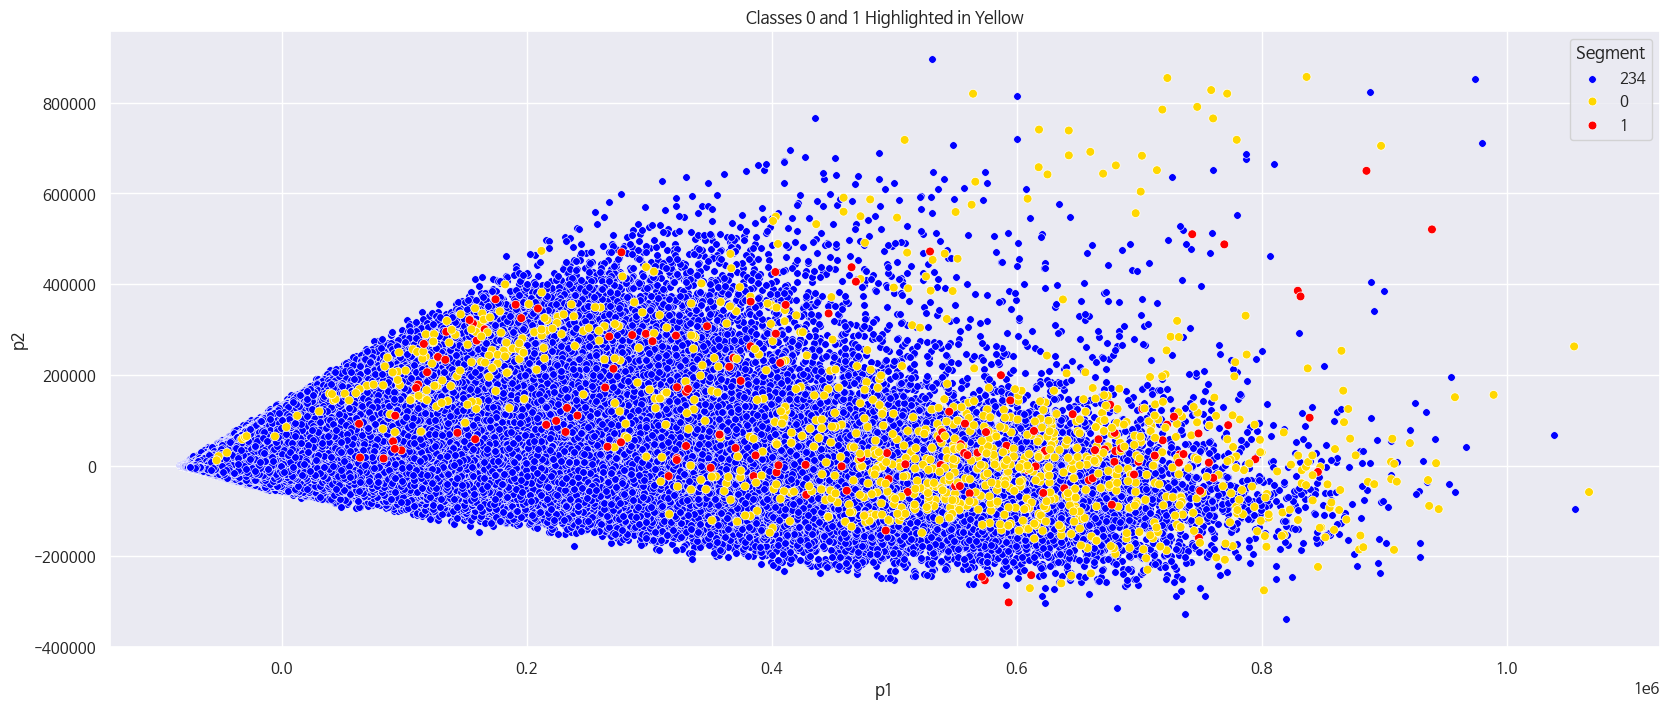

In [ ]:
# '0'과 '1' 클래스만 빨간색으로, 나머지는 연한 회색으로 표시
plt.figure(figsize=(20, 8))

# 나머지 클래스 연한 회색 표시
sns.scatterplot(
    data=pca_df[~pca_df['Segment'].isin([0, 1])],
    x='p1', y='p2',
    color='blue',
    label='234',
    s=30
)

# '0'과 '1' 클래스만 색상 지정
sns.scatterplot(
    data=pca_df[pca_df['Segment'].isin([0, 1])],
    x='p1', y='p2',
    hue='Segment',
    palette={0: 'gold', 1: 'red'},
    s=40
)

plt.legend(title='Segment')
plt.title("Classes 0 and 1 Highlighted in Yellow")
plt.show()